### Section A : Repeat the profiling exercise in lab for pbmc6k and pbmc10k datasets (coarse-grain, instrumented, fine-grain).

-	Coarse-grain: “/usr/bin/time -v” before the command.
-	Instrumented: time.time() function to measure the elapsed time for each code section marked with “#%%”
-	Fine-grain: cProfile.run for “sc.tl.rank_genes_groups”


### Section B : Create the slurm batch scripts for each experiment (including pbmc3k). Include in your PDF

```profile_pbmc3k.slurm``` (slurm batch script for pbmc3k)

In [ ]:
#!/bin/bash
#SBATCH --job-name=pbmc3k_profile
#SBATCH --output=logs/pbmc3k_%j.out
#SBATCH --error=logs/pbmc3k_%j.err
#SBATCH --time=00:02:00
#SBATCH --cpus-per-task=1
#SBATCH --mem=1G

set -euo pipefail

cd ..
source bmi500/bin/activate

/usr/bin/time -v python scanpy_pbmc.py \
  --data-dir data \
  --data-set pbmc3k \
  --out-dir profiling_output \
  --num-threads "${SLURM_CPUS_PER_TASK:-1}"

```profile_pbmc6k.slurm``` (slurm batch script for pbmc6k)

In [ ]:
#!/bin/bash
#SBATCH --job-name=pbmc6k_profile
#SBATCH --output=logs/pbmc6k_%j.out
#SBATCH --error=logs/pbmc6k_%j.err
#SBATCH --time=00:05:00
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G

set -euo pipefail

cd ..
source bmi500/bin/activate

/usr/bin/time -v python scanpy_pbmc.py \
  --data-dir data \
  --data-set pbmc6k \
  --out-dir profiling_output \
  --num-threads "${SLURM_CPUS_PER_TASK:-1}"

```profile_pbmc10k.slurm``` (slurm batch script for pbmc10k)

In [ ]:
#!/bin/bash
#SBATCH --job-name=pbmc10k_profile
#SBATCH --output=logs/pbmc10k_%j.out
#SBATCH --error=logs/pbmc10k_%j.err
#SBATCH --time=00:10:00
#SBATCH --cpus-per-task=1
#SBATCH --mem=4G

set -euo pipefail

cd ..
source bmi500/bin/activate

/usr/bin/time -v python scanpy_pbmc.py \
  --data-dir data \
  --data-set pbmc10k \
  --out-dir profiling_output \
  --num-threads "${SLURM_CPUS_PER_TASK:-1}"

### Section C : Capture console outputs for all dataset runs (pbmc3k, pbmc6k, pbmc10k) and include in your PDF. 

Highlight 
* time, CPU, and memory usage in coarse-grain timing
* major bottleneck from instrumented
* visualize cProfile results for the “rank_gene_groups” step for each dataset.

##### **C-1)** Coarse-grain timing: Time, CPU, and Memory Usage

| Dataset | Wall time | CPU time | CPU usage | Max memory |
| --- | --- | --- | --- | --- |
| pbmc3k | 17.06 s | 16.74 s | 98% | 0.83 GiB |
| pbmc6k | 23.39 s | 23.51 s | 100% | 0.86 GiB |
| pbmc10k | 75.12 s | 74.80 s | 99% | 1.26 GiB |

##### **C-2)** Major bottleneck from instrumented

If startup overhead is excluded (i.e. settings), the main computational bottleneck is the `neighbors` step. For smaller datasets, `umap` is the slowest analysis step, but as dataset size grows to 10k cells, `neighbors` becomes the clear dominant bottleneck.

##### **C-3)** Visualization of cProfile results for the "rank_gene_groups" step for each dataset

##### pbmc3k

![pbmc3k](/home/jsjun2/bmi500/profiling_output/pbmc3k_snakeviz.png)

##### pbmc6k

![pbmc6k](/home/jsjun2/bmi500/profiling_output/pbmc6k_snakeviz.png)

##### pbmc10k
Comment: For the pbmc10k dataset, I directly extracted data from .prof file as `snakeviz` was not working for this file.

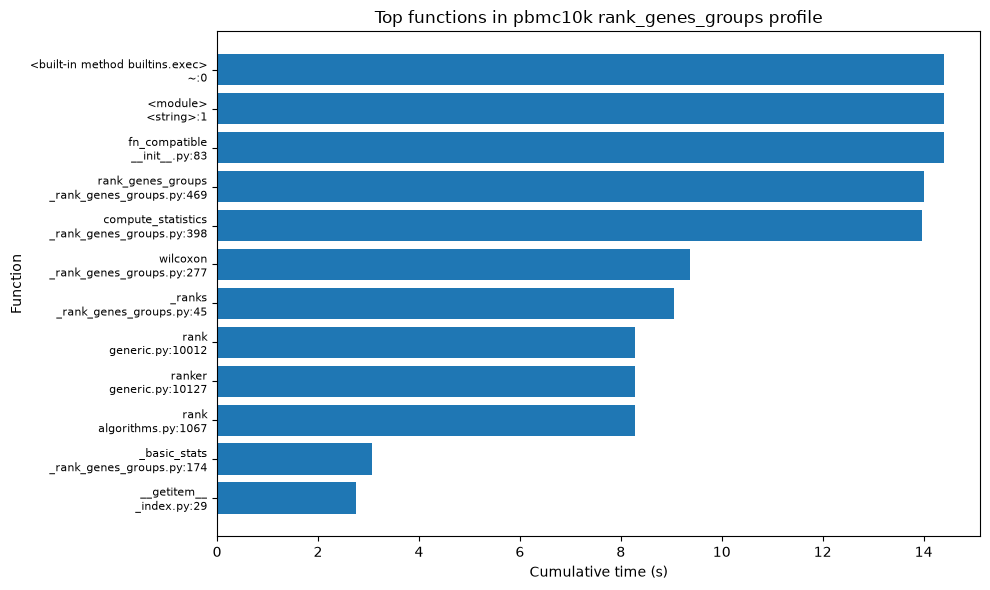

In [ ]:
import pstats
import pandas as pd
import matplotlib.pyplot as plt

prof_file = "/home/jsjun2/bmi500/profiling_output/pbmc10k.rank_genes.prof"
stats = pstats.Stats(prof_file)

rows = []
for func, stat in stats.stats.items():
    cc, nc, tt, ct, callers = stat
    filename, lineno, funcname = func
    rows.append({
        "function": f"{funcname}\n{filename.split('/')[-1]}:{lineno}",
        "ncalls": nc,
        "tottime": tt,
        "cumtime": ct,
    })

df = pd.DataFrame(rows)
df = df.sort_values("cumtime", ascending=False).head(12)

plt.figure(figsize=(10, 6))
plt.barh(df["function"][::-1], df["cumtime"][::-1])
plt.xlabel("Cumulative time (s)")
plt.ylabel("Function")
plt.title("Top functions in pbmc10k rank_genes_groups profile")
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

### Section D: plot the instrumented profile results for each code section vs dataset size (dataset on x-axis, run time on y-axis). Use stacked bar, line, or stacked area plot to show runtime growth dataset size.

In [5]:
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

log_files = {
    "pbmc3k": Path("scripts/logs/pbmc3k_1285793.out"),
    "pbmc6k": Path("scripts/logs/pbmc6k_1285794.out"),
    "pbmc10k": Path("scripts/logs/pbmc10k_1285873.out"),
}

dataset_sizes = {
    "pbmc3k": 3000,
    "pbmc6k": 6000,
    "pbmc10k": 10000,
}

pattern = re.compile(r"Time elapsed for (.*): ([0-9.]+) s")

rows = []
for dataset, path in log_files.items():
    text = path.read_text()
    row = {"dataset": dataset, "cells": dataset_sizes[dataset]}
    
    for section, seconds in pattern.findall(text):
        row[section] = float(seconds)
    
    rows.append(row)

df = pd.DataFrame(rows).sort_values("cells")
df

,dataset,cells,settings,argparse,read 10x data,filter cells and genes,normalize genes,highly variable genes,scale,pca,neighbors,louvain,umap,write_h5ad,rank gene groups
0,pbmc3k,3000,4.712532,0.000713,0.096735,0.035117,0.008672,0.019283,0.027381,0.109654,3.164485,0.079678,5.157643,0.106165,1.221826
1,pbmc6k,6000,4.687654,0.000632,0.125232,0.052624,0.012810,0.022078,0.053568,0.282124,3.225829,0.225400,10.023322,0.139986,2.545289
2,pbmc10k,10000,7.097898,0.001004,0.670879,0.430052,0.454309,0.461957,0.174585,1.068526,30.668275,0.783632,14.510254,0.746039,14.408461


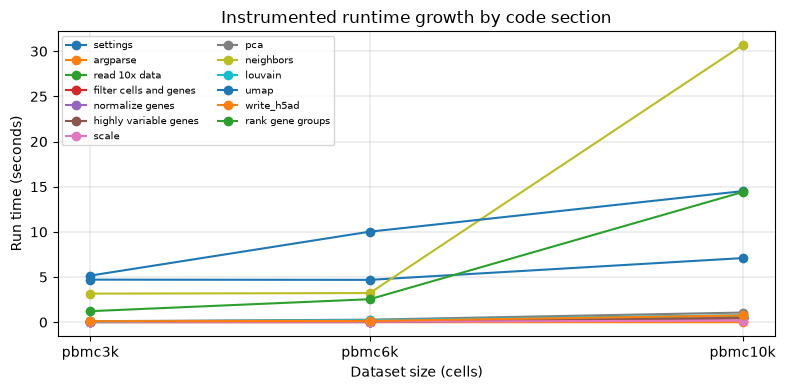

In [6]:
sections = [
    col for col in df.columns
    if col not in ["dataset", "cells"]
]

plt.figure(figsize=(8, 4))

for section in sections:
    plt.plot(df["cells"], df[section], marker="o", linewidth=1.5, label=section)

plt.xlabel("Dataset size (cells)")
plt.ylabel("Run time (seconds)")
plt.title("Instrumented runtime growth by code section")
plt.xticks(df["cells"], df["dataset"])
plt.grid(True, linewidth=0.3)
plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### Section E: Where are the performance bottlenecks? If the data size were to grow to 20K, what are the expected running times for the code sections?

The main performance bottlenecks are:
- neighbors is the biggest overall bottleneck in the analysis pipeline, especially by pbmc10k (30.61 s).
- umap is the next major bottleneck.
- rank gene groups also becomes expensive as the dataset grows.

In [7]:
import numpy as np

def estimate_runtime(section, target_cells=20000):
    x = df["cells"].to_numpy(dtype=float)
    y = df[section].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    predicted = slope * target_cells + intercept
    return {
        "section": section,
        "slope": slope,
        "intercept": intercept,
        "predicted_seconds": predicted,
    }

estimates = pd.DataFrame(
    [estimate_runtime(section, target_cells=20000) for section in sections]
).sort_values("predicted_seconds", ascending=False)

estimates[["section", "predicted_seconds"]].round(2)

,section,predicted_seconds
8,neighbors,68.22
12,rank gene groups,32.60
10,umap,28.00
0,settings,10.35
7,pca,2.40
9,louvain,1.77
11,write_h5ad,1.62
2,read 10x data,1.46
5,highly variable genes,1.07
4,normalize genes,1.06
